In [1]:
import numpy as np
import matplotlib.pyplot as plt

#AAPL parameters (annual, from Day 5)
mu = 0.395    # annual drift
sigma = 0.226 # annual volatility
S0 = 297      # starting price (today's AAPl)

In [6]:
def simulate_gbm_path(S0, mu, sigma, days, dt=1/252, seed=None):
    if seed is not None:
        np.random.seed(seed)

    prices =[S0]                        #start w/ initial price

    for _ in range(days):
        S_current = prices[-1]          #last price in the list
        Z = np.random.standard_normal() # fresh random draw, N(0,1)

        S_next = S_current * np.exp((mu - sigma**2/2)*dt + sigma * np.sqrt(dt) * Z)

        prices.append(S_next)           # add new price to the path

    return np.array(prices)

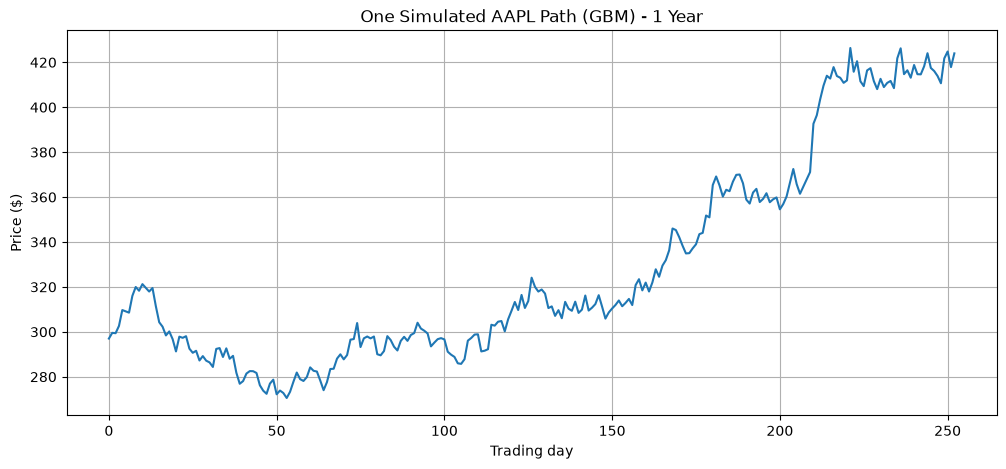

In [9]:
path = simulate_gbm_path(S0, mu, sigma, days=252, seed=42) #seed-optional, random rep

plt.figure(figsize=(12, 5))
plt.plot(path)
plt.title("One Simulated AAPL Path (GBM) - 1 Year")
plt.xlabel("Trading day")
plt.ylabel("Price ($)")
plt.grid(True)
plt.show()

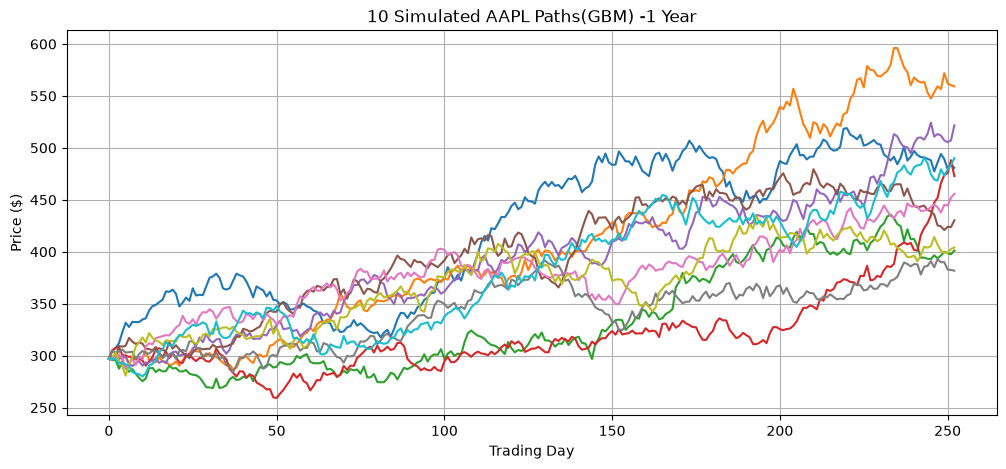

In [10]:
plt.figure(figsize=(12, 5))

for i in range(10):
    path = simulate_gbm_path(S0, mu, sigma, days=252, seed=i)
    plt.plot(path)

plt.title("10 Simulated AAPL Paths(GBM) -1 Year")
plt.xlabel("Trading Day")
plt.ylabel("Price ($)")
plt.grid(True)
plt.show()